In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load test data
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')
feature_names = joblib.load('../data/feature_names.pkl')

# Load XGBoost model
xgb_model = joblib.load('../models/xgboost_model.pkl')

# Get predictions
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

print(f"Test set shape: {X_test.shape}")
print(f"Total patients: {len(y_test)}")
print(f"Deaths in test set: {y_test.sum()}")
print(f"AUC-ROC: {round(roc_auc_score(y_test, xgb_pred_proba), 4)}")
print("Everything loaded ✅")

Test set shape: (18343, 65)
Total patients: 18343
Deaths in test set: 1583
AUC-ROC: 0.8871
Everything loaded ✅


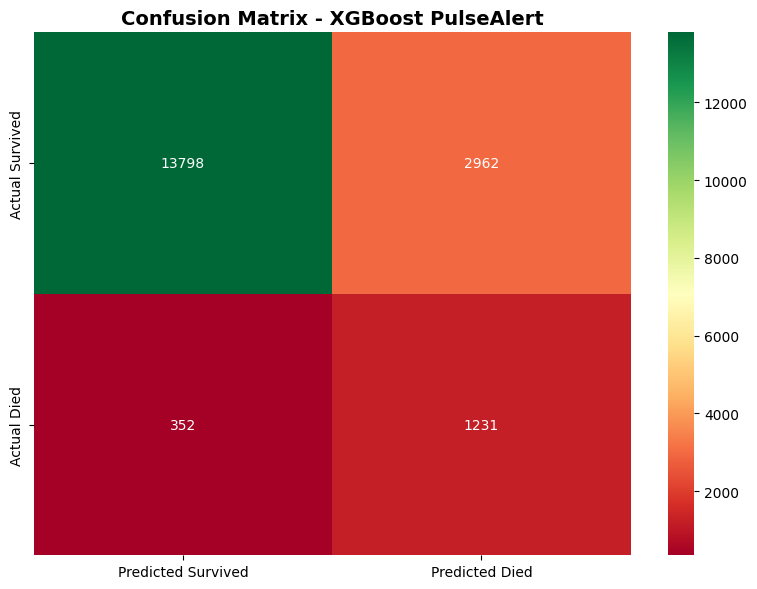

True Negatives  (Correctly predicted Survived): 13798
False Positives (Wrongly alarmed - stable patient): 2962
False Negatives (MISSED DEATHS - dangerous!): 352
True Positives  (Correctly predicted Death): 1231

Out of 1583 actual deaths:
  Caught: 1231 (77.8%)
  Missed: 352 (22.2%)

False alarm rate: 17.7% of stable patients wrongly alarmed


In [2]:
# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Predicted Survived', 'Predicted Died'],
            yticklabels=['Actual Survived', 'Actual Died'])
plt.title('Confusion Matrix - XGBoost PulseAlert', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Break down the numbers
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correctly predicted Survived): {tn}")
print(f"False Positives (Wrongly alarmed - stable patient): {fp}")
print(f"False Negatives (MISSED DEATHS - dangerous!): {fn}")
print(f"True Positives  (Correctly predicted Death): {tp}")
print(f"\nOut of {int(y_test.sum())} actual deaths:")
print(f"  Caught: {tp} ({round(tp/y_test.sum()*100,1)}%)")
print(f"  Missed: {fn} ({round(fn/y_test.sum()*100,1)}%)")
print(f"\nFalse alarm rate: {round(fp/(fp+tn)*100,1)}% of stable patients wrongly alarmed")

In [3]:
# Find optimal threshold to maximize recall
# Default threshold is 0.5 - we can lower it to catch more deaths

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    preds = (xgb_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    specificity = tn / (tn + fp)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    false_alarm_rate = fp / (fp + tn)
    
    results.append({
        'threshold': round(thresh, 2),
        'recall': round(recall, 3),
        'precision': round(precision, 3),
        'specificity': round(specificity, 3),
        'f1': round(f1, 3),
        'false_alarm_rate': round(false_alarm_rate, 3),
        'deaths_caught': tp,
        'deaths_missed': fn
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  recall  precision  specificity    f1  false_alarm_rate  deaths_caught  deaths_missed
      0.10   0.975      0.135        0.412 0.238             0.588           1543             40
      0.15   0.957      0.158        0.517 0.271             0.483           1515             68
      0.20   0.934      0.177        0.589 0.297             0.411           1478            105
      0.25   0.918      0.197        0.646 0.324             0.354           1453            130
      0.30   0.889      0.214        0.691 0.345             0.309           1408            175
      0.35   0.863      0.232        0.730 0.366             0.270           1366            217
      0.40   0.834      0.249        0.762 0.384             0.238           1321            262
      0.45   0.805      0.270        0.794 0.404             0.206           1275            308
      0.50   0.778      0.294        0.823 0.426             0.177           1231            352
      0.55   0.741      0.315 

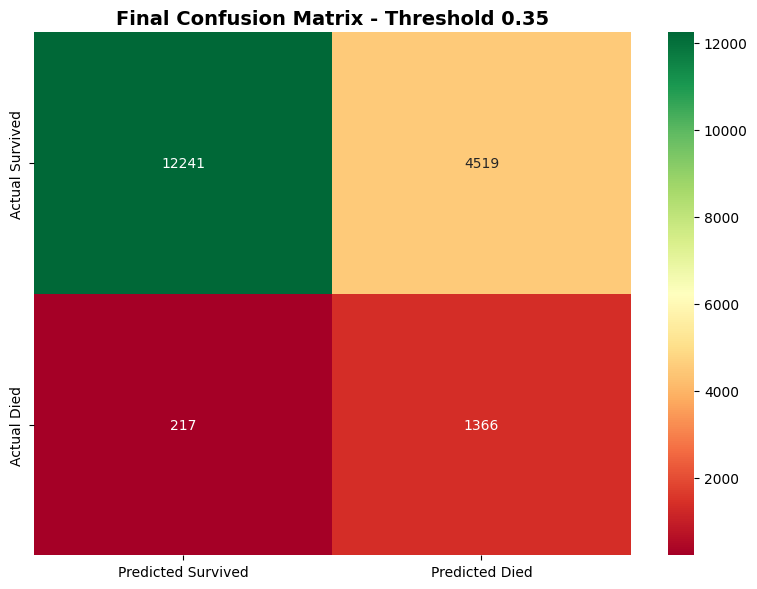

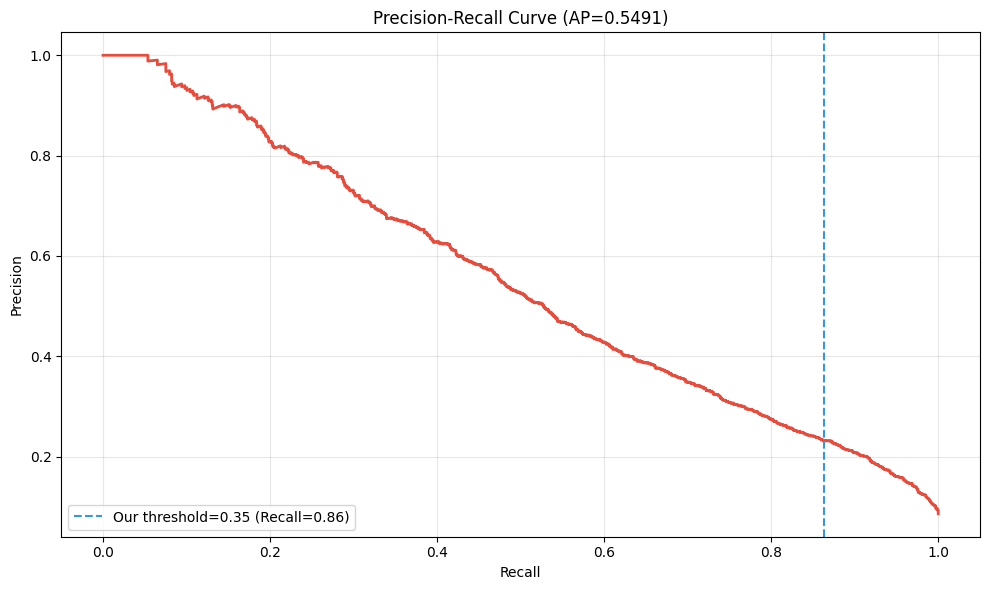

FINAL PULSEALERT MODEL METRICS (threshold=0.35)
AUC-ROC:          0.8871
Recall:           0.8629 (1366 of 1583 deaths caught)
Precision:        0.2321
Specificity:      0.7304
False alarm rate: 27.0%
Deaths caught:    1366
Deaths missed:    217

Target AUC > 0.85:     ✅ PASSED
Target Recall > 0.80:  ✅ PASSED
Target Specificity > 0.75: ❌ FAILED

Optimal threshold saved ✅

Notebook 04 - Model Evaluation COMPLETE ✅


In [4]:
# Set optimal threshold for PulseAlert
OPTIMAL_THRESHOLD = 0.35

# Final predictions with optimal threshold
final_pred = (xgb_pred_proba >= OPTIMAL_THRESHOLD).astype(int)

# Final confusion matrix
cm_final = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm_final.ravel()

# Plot final confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Predicted Survived', 'Predicted Died'],
            yticklabels=['Actual Survived', 'Actual Died'])
plt.title(f'Final Confusion Matrix - Threshold {OPTIMAL_THRESHOLD}', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Precision Recall Curve
precision_curve, recall_curve, thresh_curve = precision_recall_curve(y_test, xgb_pred_proba)
avg_precision = average_precision_score(y_test, xgb_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='#e74c3c', linewidth=2)
plt.axvline(x=tp/(tp+fn), color='#3498db', linestyle='--', 
            label=f'Our threshold={OPTIMAL_THRESHOLD} (Recall={round(tp/(tp+fn),2)})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP={round(avg_precision,4)})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"FINAL PULSEALERT MODEL METRICS (threshold={OPTIMAL_THRESHOLD})")
print(f"{'='*50}")
print(f"AUC-ROC:          {round(roc_auc_score(y_test, xgb_pred_proba), 4)}")
print(f"Recall:           {round(tp/(tp+fn), 4)} ({tp} of {int(y_test.sum())} deaths caught)")
print(f"Precision:        {round(tp/(tp+fp), 4)}")
print(f"Specificity:      {round(tn/(tn+fp), 4)}")
print(f"False alarm rate: {round(fp/(fp+tn)*100, 1)}%")
print(f"Deaths caught:    {tp}")
print(f"Deaths missed:    {fn}")
print(f"\n{'='*50}")
print(f"Target AUC > 0.85:     {'✅ PASSED' if roc_auc_score(y_test, xgb_pred_proba) > 0.85 else '❌ FAILED'}")
print(f"Target Recall > 0.80:  {'✅ PASSED' if tp/(tp+fn) > 0.80 else '❌ FAILED'}")
print(f"Target Specificity > 0.75: {'✅ PASSED' if tn/(tn+fp) > 0.75 else '❌ FAILED'}")

# Save threshold
joblib.dump(OPTIMAL_THRESHOLD, '../models/optimal_threshold.pkl')
print(f"\nOptimal threshold saved ✅")
print("\nNotebook 04 - Model Evaluation COMPLETE ✅")